## ML Classical Baselines

In [25]:
import pandas as pd
from IPython.display import display

from utils.config import (
    BANDS_TO_RUN,
    DATA_DIR,
    DEFAULT_OVERLAP_SIZE,
    DEFAULT_WINDOW_SIZE,
)
from utils.ML.ml_pipeline import (
    best_confusion_predictions,
    get_cache_path,
    get_results_path,
    load_all_predictions,
    load_feature_dataframes,
    load_lovo_summary_tables,
    load_or_build_none_reference_features,
    load_params_lookup,
    load_raw_csi_data,
    lovo_aggregated_analysis_table,
    master_results_table,
    per_room_position_accuracy_table,
    print_normalization_discriminability,
    run_global_baselines,
    run_optional_grid_search,
    save_analysis_tables,
    save_lovo_analysis_table,
)
from utils.plots import (
    plot_band_error_cdf,
    plot_block_vs_lovo_position_accuracy,
    plot_floor_plan_heatmap,
    plot_global_position_confusion_matrix,
    plot_localization_error_cdf_by_model,
    plot_lovo_fold_spread,
    plot_csi_magnitude_stages,
    plot_model_band_error_boxplot,
    plot_position_confusion_by_true_room,
)

#### Project Configurations

In [26]:
CALIBRATION_MODE = "rssi"   # ("none", "packet_norm", "rssi")

CSV_PROCESSING_OPTIONS = {
    "max_workers": 1,
    "cache_dir": None,
    "use_cache": True,
    "force_reprocess": False,
    "min_rssi_dbm": -95.0,
    "calibration_eps": 1e-12,
}

MAGNITUDE_PROCESSING_OPTIONS = {
    "normalization": "empty_baseline"
    ,  # none | zscore | minmax | packet_minmax | empty_baseline
    "epsilon": 1e-8,
}
NORMALIZATION_BASELINE_SCOPE = "per_session"  # per_session | per_user | global (empty_baseline only)
SHOW_MAGNITUDE_PLOT = True

MAGNITUDE_PLOT_OPTIONS = {
    "position": "D-8",
    "user": "03",
    "trial": "01",
    "anchor_pair": 7,
    "packet_count": 60,
    "packet_selection": "middle",
    "normalized_limit_percentile": 99.0,
    "surface_elevation": 28,
    "surface_azimuth": -135,
    "save": False,
    "output_directory": "outputs/magnitude_plots",
}

FEATURE_EXTRACTION_OPTIONS = {
    "window_size": DEFAULT_WINDOW_SIZE,
    "overlap_size": DEFAULT_OVERLAP_SIZE,
    "require_all_esps": False,
}

MODELS_TO_RUN = ("RF", "KNN", "SVM")
SPLIT_MODES = ("block", "lovo")  # cross_session, lovo, random, block
RUN_CLASSIFICATION = False
RUN_GRID_SEARCH = False
REQUIRE_TUNED_PARAMS = True  # True -> require an exact matching grid-search run
FORCE_RETRAIN = False
SAVE_PREDICTIONS = True
N_JOBS = 8

BLOCK_COUNT = 10
TEST_SIZE = 0.30
RANDOM_STATE = 42
ROW_SPACING = 1.0
COLUMN_SPACING = 1.0
SVM_FUSION_FALLBACK_SECONDS = 30 * 60

CONFUSION_DATASET = "Fusion"
CONFUSION_MODEL = "best"      # "best", "RF", "KNN", or "SVM"

SHOW_CDF_BY_BAND = True
SHOW_CDF_BY_MODEL = True
SHOW_BOXPLOT = True
SHOW_FLOOR_PLAN = True
SHOW_CONFUSION_MATRICES = True
SHOW_PER_ROOM_PLOTS = False

preproc_opts = dict(MAGNITUDE_PROCESSING_OPTIONS)
if preproc_opts.get("normalization") == "empty_baseline":
    preproc_opts["baseline_scope"] = NORMALIZATION_BASELINE_SCOPE
feat_opts = dict(FEATURE_EXTRACTION_OPTIONS)
feature_cache_dir = get_cache_path(preproc_opts, feat_opts)
results_dir = get_results_path()
print(f"Feature cache path: {feature_cache_dir}")
print(f"Results path: {results_dir}")
tables_dir = results_dir / "tables"
plots_dir = results_dir / "plots"
for directory in (tables_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)


def _slugify(value: str) -> str:
    """Convert a display value to a compact filename-safe slug."""
    return value.lower().replace(".", "-").replace(" ", "-").strip("-")

Feature cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
Results path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results


## Raw Data

In [27]:
loaded_csi_data = load_raw_csi_data(
    DATA_DIR,
    calibration_mode=CALIBRATION_MODE,
    csv_options=CSV_PROCESSING_OPTIONS,
    return_magnitude_stages=SHOW_MAGNITUDE_PLOT,
)
magnitude_data, csv_diagnostics = loaded_csi_data[:2]
magnitude_plot_stages = loaded_csi_data[2] if SHOW_MAGNITUDE_PLOT else None

Scenarios present: 1
Locations: 53 | Users: 6 | ESPs: 19


[Z-0 inventory]
  total Z-0 files found: 171
  Z-0 count per (user, trial):
    (user=01, trial=01): 19
    (user=01, trial=02): 19
    (user=02, trial=01): 19
    (user=03, trial=01): 19
    (user=03, trial=02): 19
    (user=04, trial=01): 19
    (user=05, trial=01): 19
    (user=05, trial=02): 19
    (user=06, trial=01): 19
  breakdown by user / esp / trial:
    user=01 esp=01 trial=01: 1
    user=01 esp=01 trial=02: 1
    user=01 esp=02 trial=01: 1
    user=01 esp=02 trial=02: 1
    user=01 esp=03 trial=01: 1
    user=01 esp=03 trial=02: 1
    user=01 esp=04 trial=01: 1
    user=01 esp=04 trial=02: 1
    user=01 esp=05 trial=01: 1
    user=01 esp=05 trial=02: 1
    user=01 esp=07 trial=01: 1
    user=01 esp=07 trial=02: 1
    user=01 esp=08 trial=01: 1
    user=01 esp=08 trial=02: 1
    user=01 esp=09 trial=01: 1
    user=01 esp=09 trial=02: 1
    user=01 esp=10 trial=01: 1
    user=01 esp=10 trial=02: 1
    user=01 esp=11 trial=01: 1
    user=01 esp=11 trial=02: 1
    user=01 esp=1

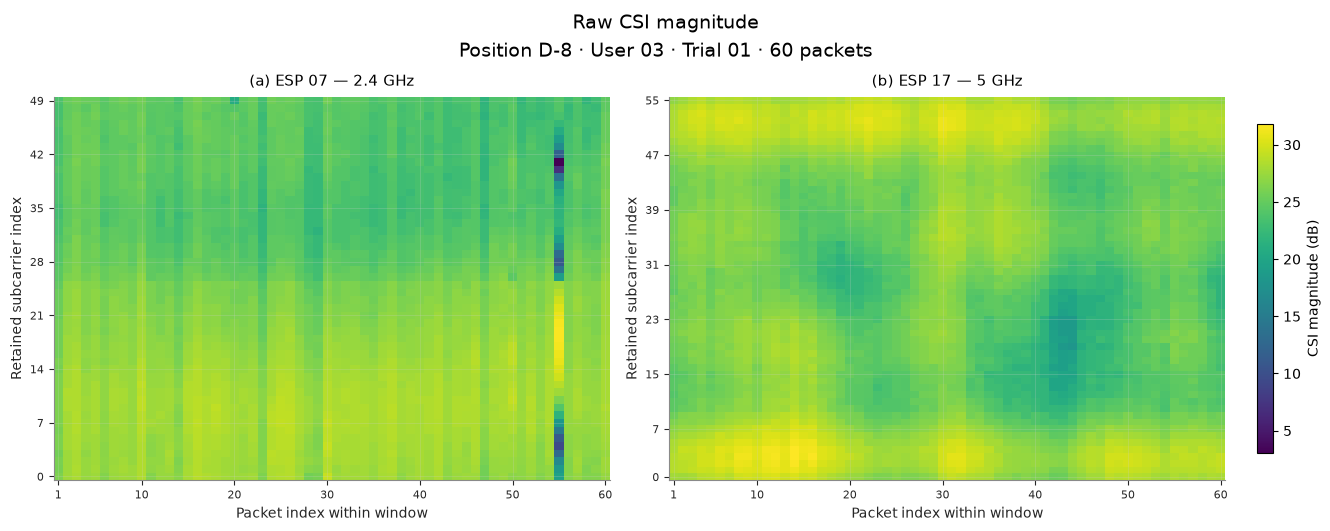

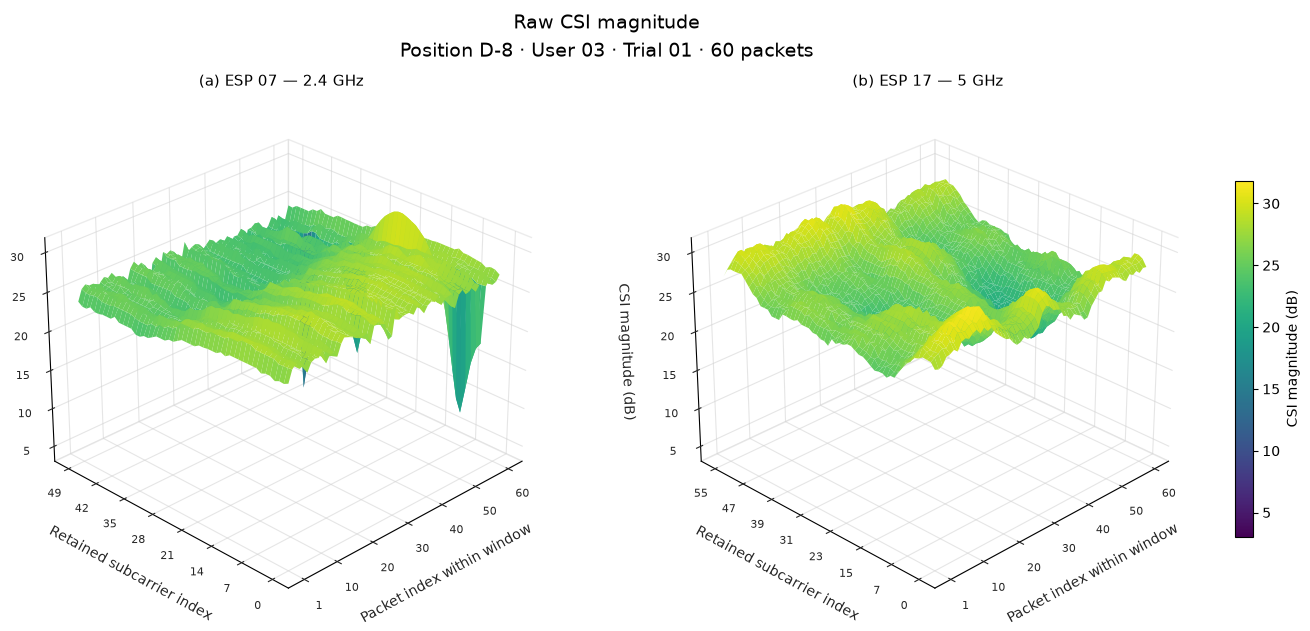

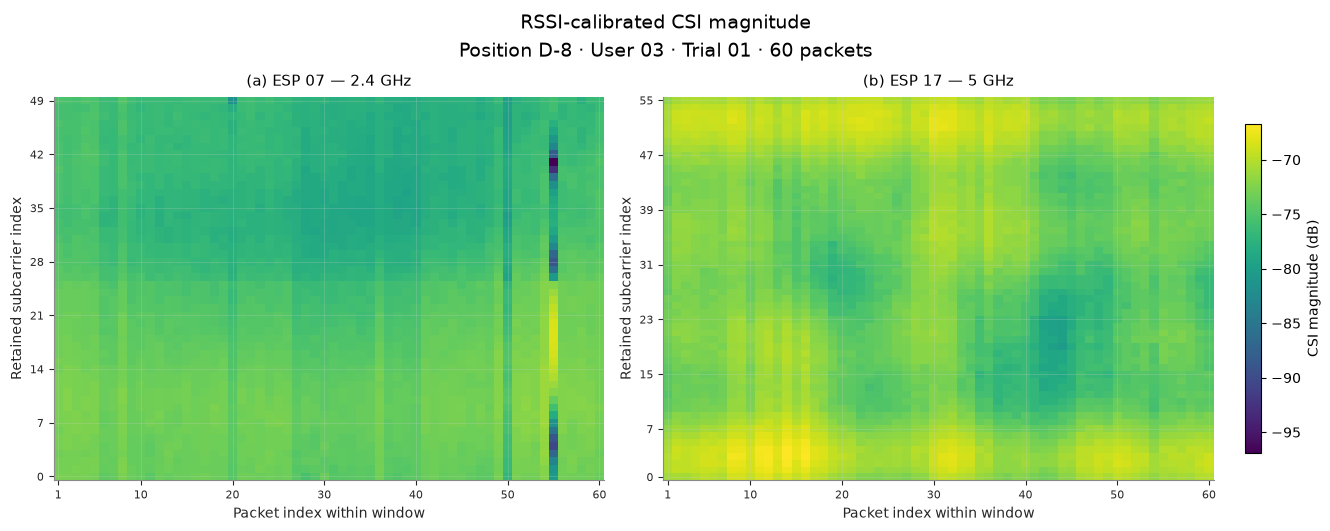

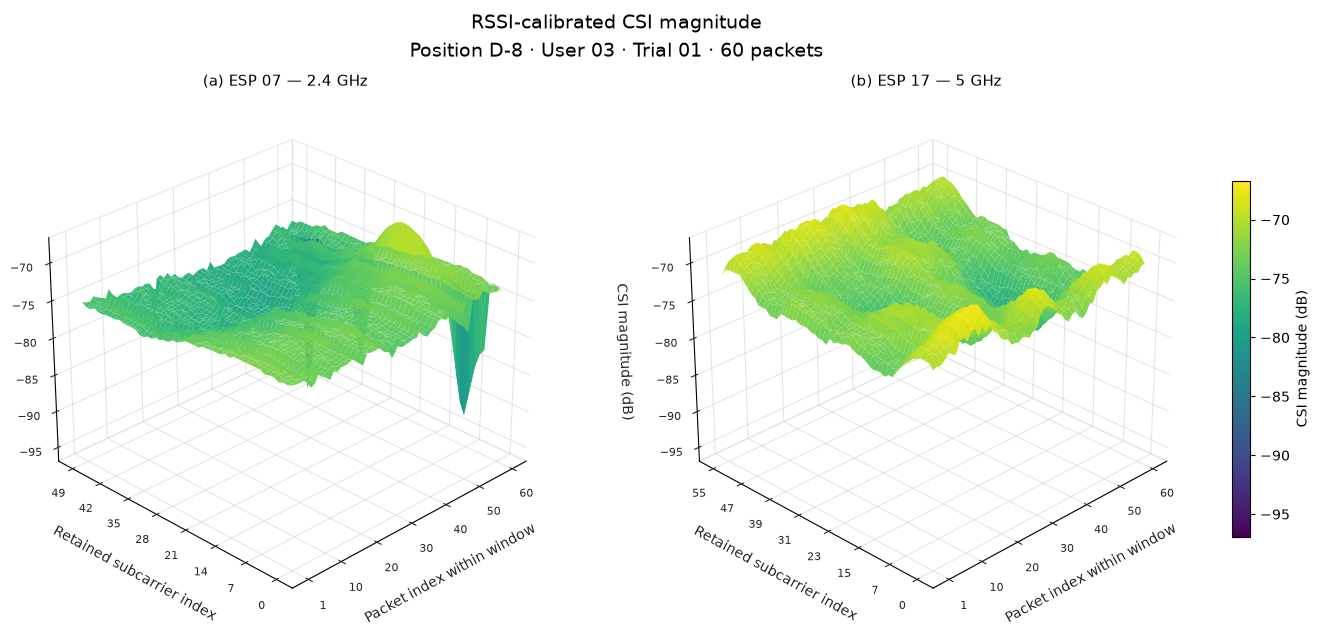

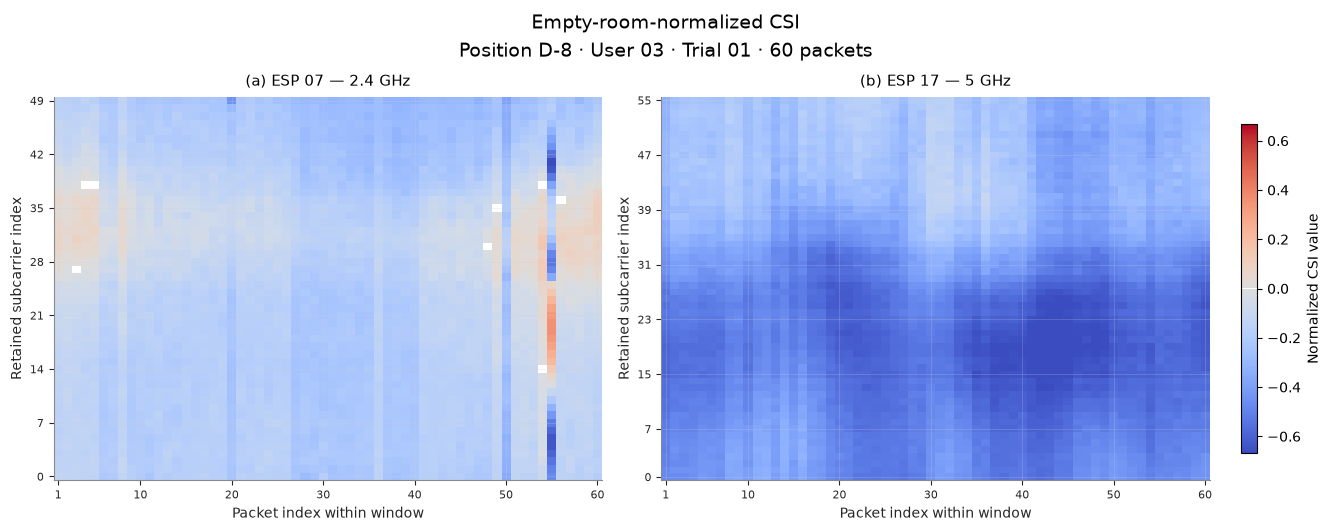

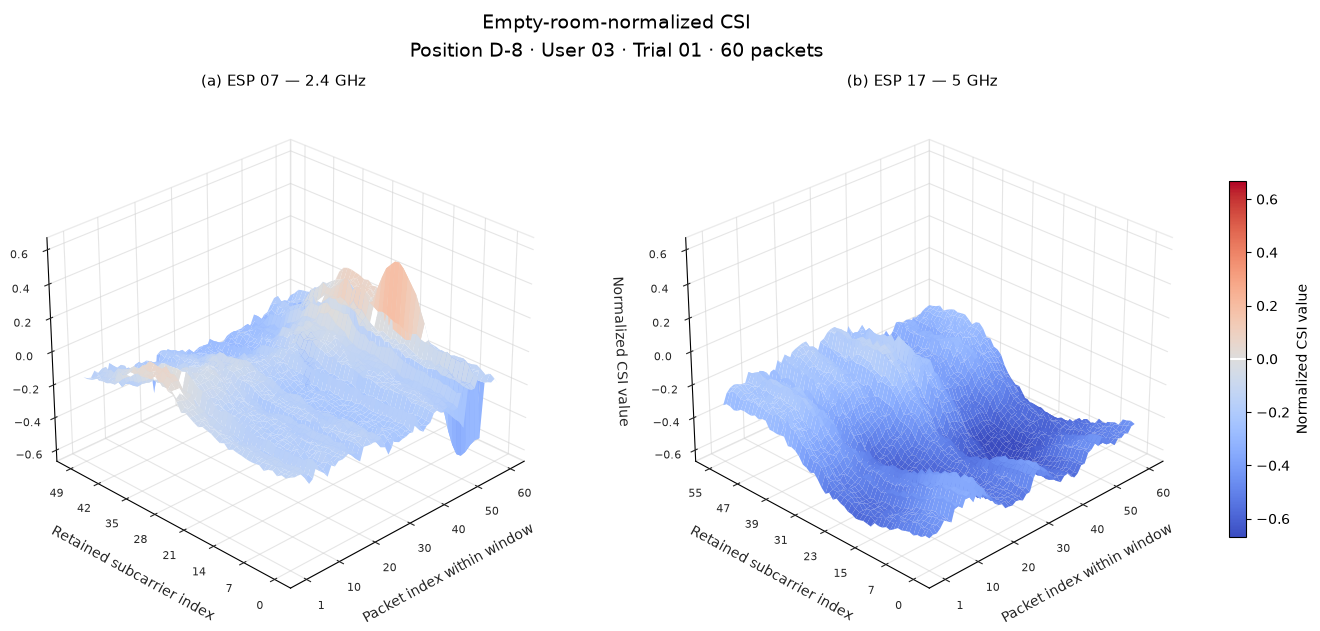

In [28]:
if SHOW_MAGNITUDE_PLOT:
    plot_csi_magnitude_stages(magnitude_plot_stages, **MAGNITUDE_PLOT_OPTIONS)

#### Feature Dataframes

In [29]:
feature_dataframes = load_feature_dataframes(
    magnitude_data,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    bands_to_run=BANDS_TO_RUN,
)

none_reference_dataframes = (
    feature_dataframes
    if preproc_opts.get("normalization") == "none"
    else load_or_build_none_reference_features(
        magnitude_data,
        active_preproc_opts=preproc_opts,
        feat_opts=feat_opts,
    )
)
fisher_diagnostics = print_normalization_discriminability(
    feature_dataframes,
    normalization=preproc_opts.get("normalization", "none"),
    reference_feature_dataframes=none_reference_dataframes,
    bands_to_run=BANDS_TO_RUN,
)
display(fisher_diagnostics)
del magnitude_data


[features] resolved cache path: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/2_4ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/5ghz.parquet
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-empty_baseline_scope-per_session/feat=win60-step0/fusion.parquet
2.4 GHz: 13588 windows, 2708 columns
5 GHz: 14478 windows, 3368 columns
Fusion: 13568 windows, 6068 columns
[normalization diagnostic] none reference cache: /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc=norm-none/feat=win60-step0
[cache hit] /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/.cache/dataframes/preproc

,dataset,normalization,median_fisher_ratio,none_median_fisher_ratio
0,2.4 GHz,empty_baseline,0.069480,0.028427
1,5 GHz,empty_baseline,0.067411,0.030535
2,Fusion,empty_baseline,0.069267,0.029641


#### Model Parameters

In [30]:
params_lookup = {}
if RUN_GRID_SEARCH:
    print("Parameter lookup deferred until the requested grid search completes.")
else:
    params_lookup = load_params_lookup(
        results_dir,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        require_tuned_params=REQUIRE_TUNED_PARAMS,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
    )
    for key, value in params_lookup.items():
        print(f"{key}: {value}")

[tuned params] exact runs.csv match: RF / 2.4 GHz / run_id=ml__rf__2_4ghz__grid_search__ebl-session__s42__d8d534
[tuned params] exact runs.csv match: RF / 5 GHz / run_id=ml__rf__5ghz__grid_search__ebl-session__s42__0249b6
[tuned params] exact runs.csv match: RF / Fusion / run_id=ml__rf__fusion__grid_search__ebl-session__s42__666a25
[tuned params] exact runs.csv match: KNN / 2.4 GHz / run_id=ml__knn__2_4ghz__grid_search__ebl-session__s42__d47768
[tuned params] exact runs.csv match: KNN / 5 GHz / run_id=ml__knn__5ghz__grid_search__ebl-session__s42__80bca5
[tuned params] exact runs.csv match: KNN / Fusion / run_id=ml__knn__fusion__grid_search__ebl-session__s42__5b6367
[tuned params] exact runs.csv match: SVM / 2.4 GHz / run_id=ml__svm__2_4ghz__grid_search__ebl-session__s42__3be980
[tuned params] exact runs.csv match: SVM / 5 GHz / run_id=ml__svm__5ghz__grid_search__ebl-session__s42__0f2dc1
[tuned params] exact runs.csv match: SVM / Fusion / run_id=ml__svm__fusion__grid_search__ebl-session

##### Optional Grid Search

In [31]:
grid_ran = run_optional_grid_search(
    feature_dataframes,
    run_grid_search=RUN_GRID_SEARCH,
    results_dir=results_dir,
    preproc_opts=preproc_opts,
    feat_opts=feat_opts,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    n_blocks=BLOCK_COUNT,
    row_spacing=ROW_SPACING,
    column_spacing=COLUMN_SPACING,
)
if grid_ran:
    raise SystemExit("RUN_GRID_SEARCH=True completed; set it to False before running experiments.")

#### Global 52-Class Baselines

In [32]:
if RUN_CLASSIFICATION:
    global_summary, global_predictions_by_key = run_global_baselines(
        feature_dataframes,
        params_lookup=params_lookup,
        models_to_run=MODELS_TO_RUN,
        bands_to_run=BANDS_TO_RUN,
        split_modes=SPLIT_MODES,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        n_blocks=BLOCK_COUNT,
        n_jobs=N_JOBS,
        results_dir=results_dir,
        preproc_opts=preproc_opts,
        feat_opts=feat_opts,
        force_retrain=FORCE_RETRAIN,
        save_predictions=SAVE_PREDICTIONS,
        svm_fallback_seconds=SVM_FUSION_FALLBACK_SECONDS,
        row_spacing=ROW_SPACING,
        column_spacing=COLUMN_SPACING,
    )
    display(global_summary)
    run_registry = pd.read_csv(results_dir / "runs.csv")
    active_run_ids = run_registry.loc[
        run_registry["model"].isin([model.lower() for model in MODELS_TO_RUN])
        & run_registry["split"].isin(SPLIT_MODES),
        "run_id",
    ]
    if active_run_ids.empty:
        raise RuntimeError("No active run_id is available for plot storage.")
    plots_dir = results_dir / "plots" / active_run_ids.iloc[0]
    plots_dir.mkdir(parents=True, exist_ok=True)
else:
    print("Classification skipped because RUN_CLASSIFICATION is False.")


Classification skipped because RUN_CLASSIFICATION is False.


#### Analysis Tables

In [33]:
all_global_predictions = load_all_predictions(
    results_dir,
    models_to_run=MODELS_TO_RUN,
    bands_to_run=BANDS_TO_RUN,
    split_modes=SPLIT_MODES,
)

master_table = master_results_table(
    all_global_predictions,
    summary_path=results_dir / "runs.csv",
)
per_room_table = per_room_position_accuracy_table(all_global_predictions)
save_analysis_tables(master_table, per_room_table, tables_dir=tables_dir)

display(master_table)
display(per_room_table)

[tables] per-room predictions remain analysis-only and are not a runs.csv view.


,model,dataset,split,position_accuracy,macro_f1,room_accuracy,mean_distance_error,median_distance_error,rmse_distance_error,p90_distance_error,...,rmse_distance_error_std,p90_distance_error_mean,p90_distance_error_std,position_accuracy_pooled,majority_position_accuracy,majority_room_accuracy,fit_seconds,predict_seconds,wall_seconds,used_estimator
0,KNN,2.4 GHz,block,0.62069,0.626367,0.932471,1.210821,0.0,2.517182,4.123106,...,NaN,NaN,NaN,NaN,0.025144,0.651580,0.201338,0.696065,0.923813,KNeighborsClassifier
1,KNN,2.4 GHz,lovo,0.0898 +/- 0.0309,0.0855 +/- 0.0327,0.4889 +/- 0.0770,5.1466 +/- 0.3095,4.1327 +/- 0.3244,6.4296 +/- 0.2522,11.2002 +/- 0.2558,...,0.252157,11.200244,0.255826,0.090389,0.020705,0.651420,0.000000,0.000000,0.000000,cached_predictions
2,RF,2.4 GHz,block,0.798132,0.799427,0.969109,0.54515,0.0,1.648754,2.0,...,NaN,NaN,NaN,NaN,0.025144,0.651580,6.827108,0.194984,7.045492,RandomForestClassifier
3,RF,2.4 GHz,lovo,0.1737 +/- 0.0557,0.1387 +/- 0.0567,0.5844 +/- 0.0740,3.9853 +/- 0.2617,3.1550 +/- 0.6746,5.2729 +/- 0.3020,9.3593 +/- 1.1335,...,0.302031,9.359268,1.133544,0.174601,0.020705,0.651420,0.000000,0.000000,0.000000,cached_predictions
4,SVM,2.4 GHz,block,0.719109,0.721358,0.948994,0.860698,0.0,2.102783,3.162278,...,NaN,NaN,NaN,NaN,0.025144,0.651580,14.268487,14.336501,28.628788,SVC
5,SVM,2.4 GHz,lovo,0.1614 +/- 0.0686,0.1442 +/- 0.0691,0.6382 +/- 0.0970,4.0503 +/- 0.3413,3.1944 +/- 0.5960,5.3524 +/- 0.5592,9.4565 +/- 1.4454,...,0.559188,9.456515,1.445400,0.163934,0.020705,0.651420,0.000000,0.000000,0.000000,cached_predictions
6,KNN,5 GHz,block,0.430825,0.432867,0.899879,1.622549,1.0,2.668019,4.123106,...,NaN,NaN,NaN,NaN,0.021845,0.660801,0.312899,1.075773,1.424527,KNeighborsClassifier
7,KNN,5 GHz,lovo,0.0728 +/- 0.0180,0.0615 +/- 0.0174,0.3913 +/- 0.1187,5.2942 +/- 0.7426,4.7643 +/- 0.8726,6.3329 +/- 0.8258,10.5364 +/- 1.3343,...,0.825797,10.536431,1.334294,0.072924,0.019599,0.655680,0.000000,0.000000,0.000000,cached_predictions
8,RF,5 GHz,block,0.803398,0.800625,0.98665,0.402393,0.0,1.105481,1.414214,...,NaN,NaN,NaN,NaN,0.021845,0.660801,29.345752,0.202651,29.580212,RandomForestClassifier
9,RF,5 GHz,lovo,0.1240 +/- 0.0587,0.0971 +/- 0.0431,0.6659 +/- 0.1410,3.7053 +/- 0.5488,3.5223 +/- 0.5589,4.4725 +/- 0.5609,7.3312 +/- 1.0406,...,0.560860,7.331167,1.040647,0.124188,0.019599,0.655680,0.000000,0.000000,0.000000,cached_predictions


,model,dataset,split,true_room,samples,position_accuracy
0,KNN,2.4 GHz,block,1,907,0.604190
1,KNN,2.4 GHz,block,2,268,0.660448
2,KNN,2.4 GHz,block,3,217,0.640553
3,KNN,2.4 GHz,lovo,1,5799,0.088291
4,KNN,2.4 GHz,lovo,2,1707,0.101347
5,KNN,2.4 GHz,lovo,3,1400,0.085714
6,RF,2.4 GHz,block,1,907,0.796031
7,RF,2.4 GHz,block,2,268,0.794776
8,RF,2.4 GHz,block,3,217,0.811060
9,RF,2.4 GHz,lovo,1,5799,0.156406


#### LOVO cross-user analysis


[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/lovo-rf-fold-spread.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


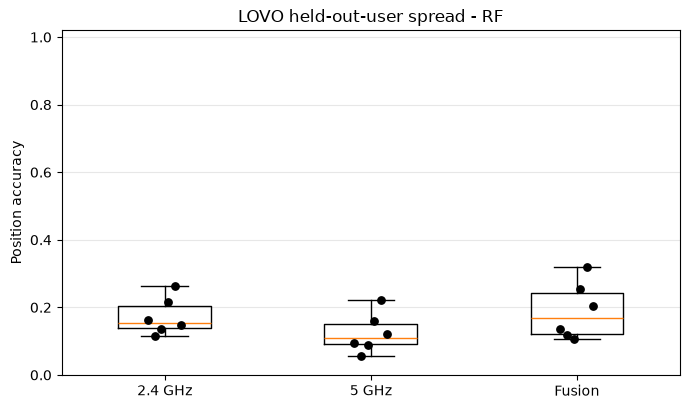

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/block-vs-lovo-rf-position-accuracy.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


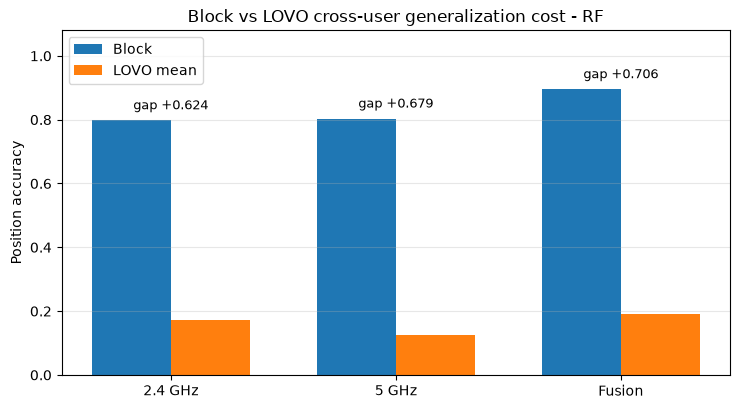

,model,dataset,position_accuracy_mean_std,macro_f1_mean_std,room_accuracy_mean_std,mean_distance_error_mean_std,median_distance_error_mean_std,rmse_distance_error_mean_std,p90_distance_error_mean_std,majority_position_accuracy_mean_std,majority_room_accuracy_mean_std
0,CNN,2.4 GHz,0.1122 +/- 0.0291,0.0924 +/- 0.0247,0.6122 +/- 0.1041,4.1370 +/- 0.4167,3.3422 +/- 0.4423,5.3155 +/- 0.5395,9.2965 +/- 1.2095,0.0207 +/- 0.0011,0.6514 +/- 0.0134
1,CNN,2.4 GHz,0.1233 +/- 0.0371,0.1033 +/- 0.0319,0.6512 +/- 0.1066,3.9754 +/- 0.5748,3.1592 +/- 0.6504,5.1265 +/- 0.6259,8.8500 +/- 1.3466,0.0207 +/- 0.0011,0.6514 +/- 0.0134
2,CNN,2.4 GHz,0.1154 +/- 0.0405,0.0971 +/- 0.0340,0.6196 +/- 0.0758,4.1702 +/- 0.4641,3.2882 +/- 0.4743,5.3888 +/- 0.5167,9.3962 +/- 1.1460,0.0207 +/- 0.0011,0.6514 +/- 0.0134
3,KNN,2.4 GHz,0.0898 +/- 0.0309,0.0855 +/- 0.0327,0.4889 +/- 0.0770,5.1466 +/- 0.3095,4.1327 +/- 0.3244,6.4296 +/- 0.2522,11.2002 +/- 0.2558,0.0207 +/- 0.0011,0.6514 +/- 0.0134
4,RF,2.4 GHz,0.1737 +/- 0.0557,0.1387 +/- 0.0567,0.5844 +/- 0.0740,3.9853 +/- 0.2617,3.1550 +/- 0.6746,5.2729 +/- 0.3020,9.3593 +/- 1.1335,0.0207 +/- 0.0011,0.6514 +/- 0.0134
5,SVM,2.4 GHz,0.1614 +/- 0.0686,0.1442 +/- 0.0691,0.6382 +/- 0.0970,4.0503 +/- 0.3413,3.1944 +/- 0.5960,5.3524 +/- 0.5592,9.4565 +/- 1.4454,0.0207 +/- 0.0011,0.6514 +/- 0.0134
6,CNN,5 GHz,0.0854 +/- 0.0270,0.0590 +/- 0.0202,0.6420 +/- 0.1635,3.8956 +/- 0.7010,3.6346 +/- 0.7403,4.7077 +/- 0.7983,7.4565 +/- 1.3491,0.0196 +/- 0.0003,0.6557 +/- 0.0037
7,CNN,5 GHz,0.0732 +/- 0.0258,0.0520 +/- 0.0242,0.6230 +/- 0.1413,4.0531 +/- 0.5039,3.6232 +/- 0.4970,4.9107 +/- 0.5632,8.0388 +/- 1.1196,0.0196 +/- 0.0003,0.6557 +/- 0.0037
8,CNN,5 GHz,0.0743 +/- 0.0152,0.0492 +/- 0.0107,0.6419 +/- 0.1672,4.0324 +/- 0.8739,3.7273 +/- 0.8534,4.8508 +/- 1.0276,7.8630 +/- 1.6934,0.0196 +/- 0.0003,0.6557 +/- 0.0037
9,KNN,5 GHz,0.0728 +/- 0.0180,0.0615 +/- 0.0174,0.3913 +/- 0.1187,5.2942 +/- 0.7426,4.7643 +/- 0.8726,6.3329 +/- 0.8258,10.5364 +/- 1.3343,0.0196 +/- 0.0003,0.6557 +/- 0.0037


,run_id,fold,held_out_user,validation_user,n_train_windows,n_test_windows,trials_used,position_accuracy,macro_f1,room_accuracy,...,wall_seconds,parameter_count,best_val_accuracy,best_epoch,mean_seconds_per_epoch,samples,stopped_epoch,patience_triggered,model,dataset
72,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,1,01,NaN,7336,1570,1,0.161783,0.124330,0.531210,...,NaN,NaN,NaN,NaN,NaN,1570.0,NaN,NaN,RF,2.4 GHz
73,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,2,02,NaN,7492,1414,1,0.114569,0.083670,0.515559,...,NaN,NaN,NaN,NaN,NaN,1414.0,NaN,NaN,RF,2.4 GHz
74,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,3,03,NaN,7319,1587,1,0.137366,0.099238,0.514178,...,NaN,NaN,NaN,NaN,NaN,1587.0,NaN,NaN,RF,2.4 GHz
75,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,4,04,NaN,7346,1560,1,0.217308,0.171542,0.689744,...,NaN,NaN,NaN,NaN,NaN,1560.0,NaN,NaN,RF,2.4 GHz
76,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,5,05,NaN,7420,1486,1,0.263122,0.237218,0.625168,...,NaN,NaN,NaN,NaN,NaN,1486.0,NaN,NaN,RF,2.4 GHz
77,ml__rf__2_4ghz__lovo__ebl-session__s42__447058,6,06,NaN,7617,1289,1,0.148177,0.116337,0.630721,...,NaN,NaN,NaN,NaN,NaN,1289.0,NaN,NaN,RF,2.4 GHz
90,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,1,01,NaN,8067,1628,1,0.095209,0.075580,0.671376,...,NaN,NaN,NaN,NaN,NaN,1628.0,NaN,NaN,RF,5 GHz
91,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,2,02,NaN,8097,1598,1,0.056946,0.050668,0.591364,...,NaN,NaN,NaN,NaN,NaN,1598.0,NaN,NaN,RF,5 GHz
92,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,3,03,NaN,8081,1614,1,0.089839,0.069183,0.432466,...,NaN,NaN,NaN,NaN,NaN,1614.0,NaN,NaN,RF,5 GHz
93,ml__rf__5ghz__lovo__ebl-session__s42__694ab2,4,04,NaN,8060,1635,1,0.159633,0.127025,0.813456,...,NaN,NaN,NaN,NaN,NaN,1635.0,NaN,NaN,RF,5 GHz


In [34]:
if "lovo" in SPLIT_MODES:
    lovo_per_fold, lovo_summary = load_lovo_summary_tables(results_dir)
    lovo_table = lovo_aggregated_analysis_table(lovo_summary)
    save_lovo_analysis_table(lovo_table, tables_dir=tables_dir)

    plot_lovo_fold_spread(
        lovo_per_fold,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('lovo rf fold spread')}.png",
    )
    plot_block_vs_lovo_position_accuracy(
        master_table,
        lovo_summary,
        bands=BANDS_TO_RUN,
        model="RF",
        save_path=plots_dir / f"{_slugify('block vs lovo rf position accuracy')}.png",
    )

    display(lovo_table)
    display(
        lovo_per_fold.loc[
            lovo_per_fold["model"].str.upper() == "RF"
        ]
    )
else:
    print("LOVO analysis skipped because 'lovo' is not in SPLIT_MODES.")

#### Analysis Figures

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_2-4-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


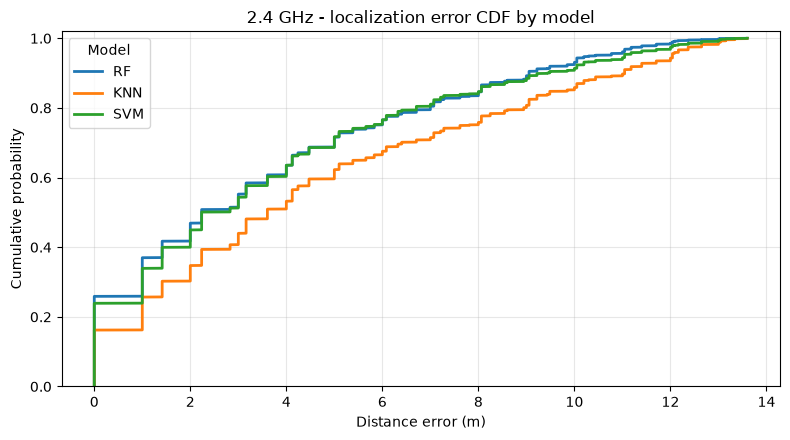

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_5-ghz.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


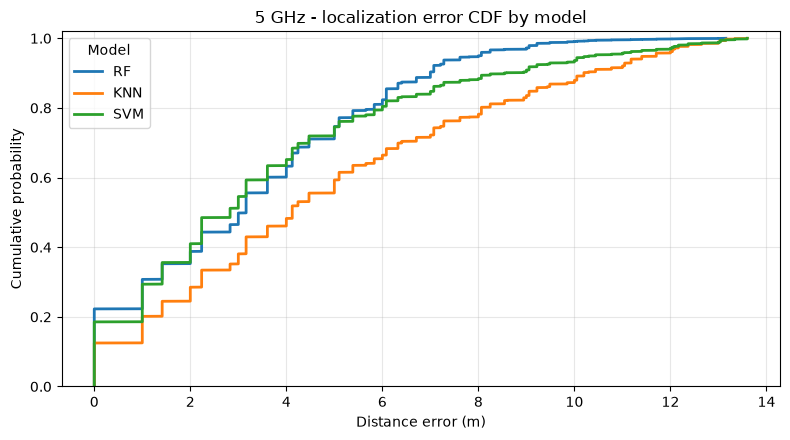

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_by_model_fusion.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


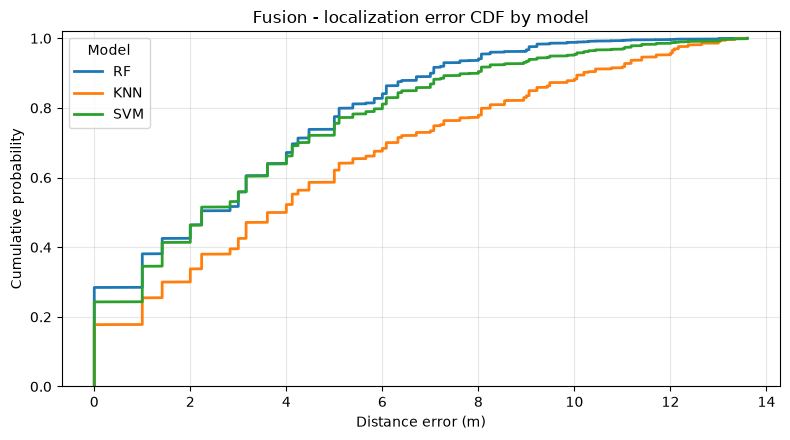

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_rf_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


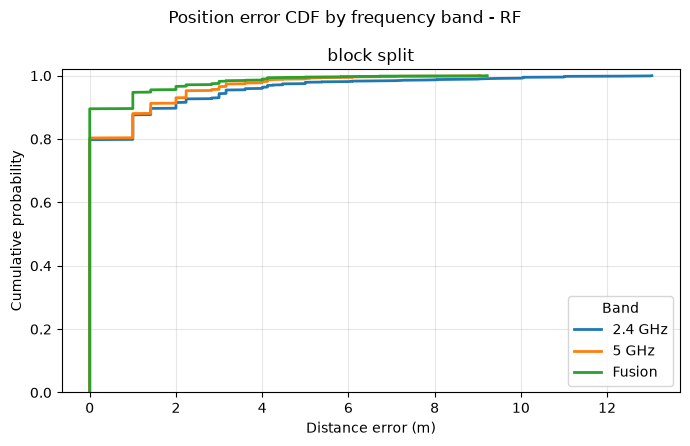

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_rf_all-bands_lovo.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


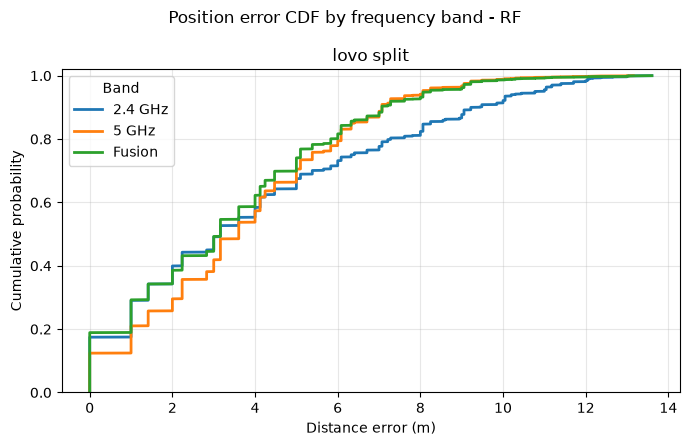

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_knn_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


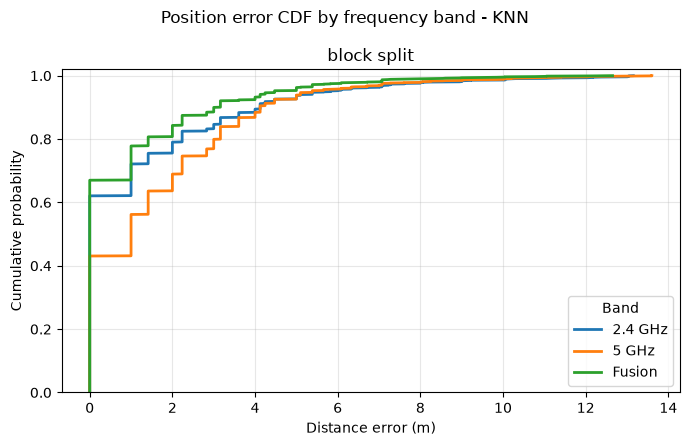

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_knn_all-bands_lovo.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


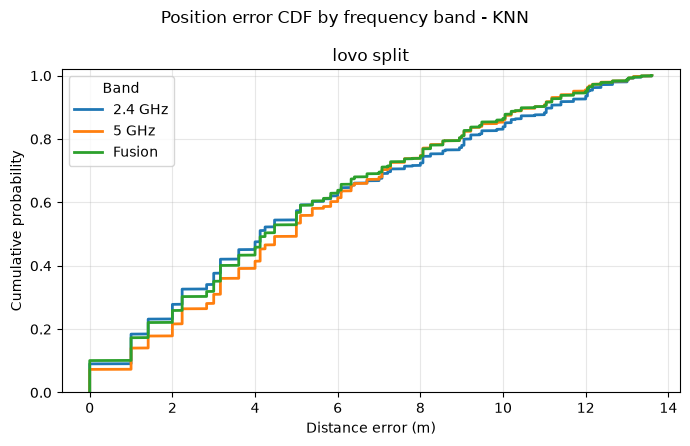

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_svm_all-bands_block.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


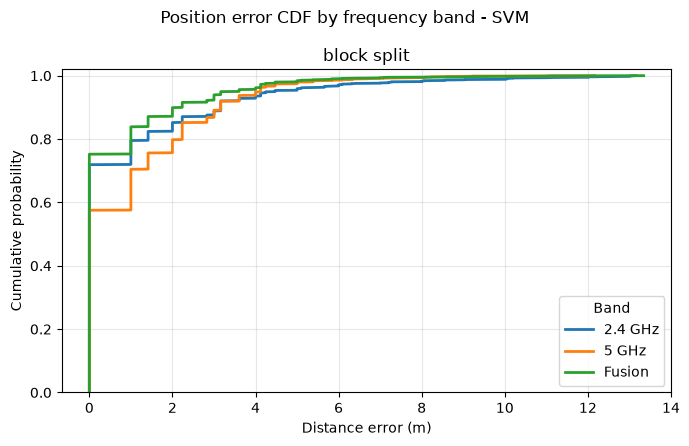

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/cdf_svm_all-bands_lovo.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


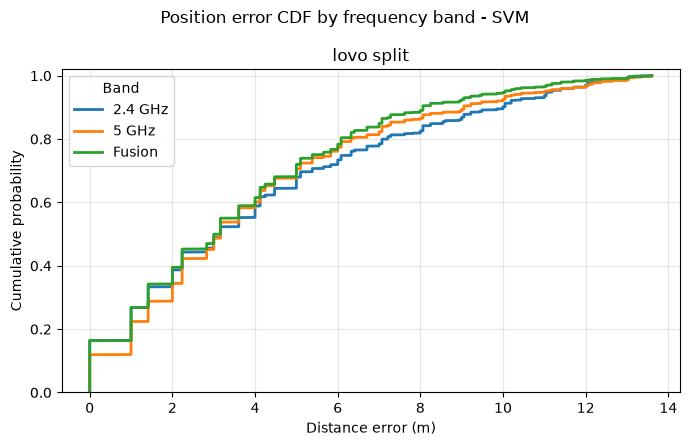

[plots] saved /home/pedro.monteiro@co.it.pt/Desktop/thesis-project/results/plots/boxplot_model_band_distance_error.png at dpi=200. PNG is raster; set PLOT_FORMAT='pdf' for a LaTeX vector figure without other changes.


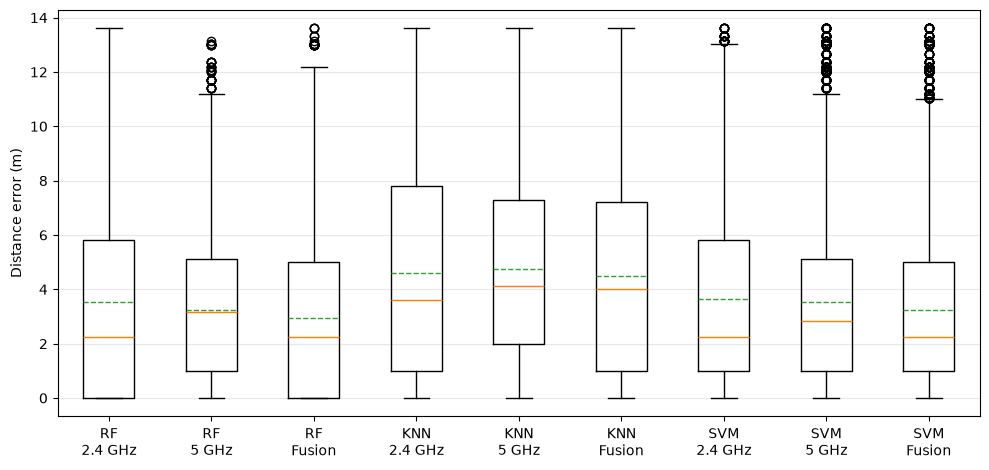

In [35]:
if SHOW_CDF_BY_BAND:
    for band in BANDS_TO_RUN:
        plot_localization_error_cdf_by_model(
            all_global_predictions,
            dataset=band,
            save_path=plots_dir / f"cdf_by_model_{_slugify(band)}.png",
        )

if SHOW_CDF_BY_MODEL:
    for model in MODELS_TO_RUN:
        model_predictions = all_global_predictions.loc[all_global_predictions["model"] == model]
        plot_band_error_cdf(
            model_predictions,
            model_label=model,
            split_modes=SPLIT_MODES,
            band_order=BANDS_TO_RUN,
            save_path=plots_dir,
        )

if SHOW_BOXPLOT:
    plot_model_band_error_boxplot(
        all_global_predictions,
        models=MODELS_TO_RUN,
        bands=BANDS_TO_RUN,
        save_path=plots_dir / "boxplot_model_band_distance_error.png",
    )

#### Confusion Matrix And Floor Plan

In [36]:
confusion_model, confusion_predictions = best_confusion_predictions(
    all_global_predictions,
    master_table,
    dataset=CONFUSION_DATASET,
    model=CONFUSION_MODEL,
)
print(f"Confusion/floor-plan model: {confusion_model} on {CONFUSION_DATASET}")

if SHOW_FLOOR_PLAN:
    plot_floor_plan_heatmap(
        confusion_predictions,
        title=f"{CONFUSION_DATASET} / {confusion_model} localization heatmap",
        save_path=plots_dir / f"floor_plan_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )

if SHOW_CONFUSION_MATRICES:
    plot_global_position_confusion_matrix(
        confusion_predictions,
        dataset=CONFUSION_DATASET,
        normalize="true",
        save_path=plots_dir / f"confusion_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}.png",
    )
    if SHOW_PER_ROOM_PLOTS:
        room_plot_dir = plots_dir / f"confusion_by_room_{_slugify(CONFUSION_DATASET)}_{_slugify(confusion_model)}"
        plot_position_confusion_by_true_room(
            confusion_predictions,
            dataset=CONFUSION_DATASET,
            normalize="true",
            save_path=room_plot_dir,
        )

TypeError: '<' not supported between instances of 'float' and 'str'